# Customer Lifetime Value (CLTV) Analysis

## Objective

The objective of this notebook is to estimate Customer Lifetime Value (CLTV) using the cleaned Olist e-commerce dataset prepared during the data cleaning phase.

This analysis helps identify high-value customers by examining their purchasing behaviour, revenue contribution, and ordering frequency. The results can be used for customer retention strategies, personalised marketing campaigns, and business decision-making.

## **Import Libraries**

In [28]:
import pandas as pd
import numpy as np

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## **Load Dataset**

In [31]:
master = pd.read_csv('cleaned_master_dataset.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## **Dataset Shape**

In [32]:
master.shape

(82365, 39)

In [33]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,7c396fd4830fd04220f754e42b4e5bff,3149,...,13,20,Unknown,2017,10,4,2,8,-8,On Time
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,7c396fd4830fd04220f754e42b4e5bff,3149,...,13,20,Unknown,2017,10,4,2,8,-8,On Time
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,7c396fd4830fd04220f754e42b4e5bff,3149,...,13,20,Unknown,2017,10,4,2,8,-8,On Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018,af07308b275d755c9edb36a90c618231,47813,...,13,19,perfumery,2018,7,3,24,13,-6,On Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19,21,auto,2018,8,3,8,9,-18,On Time


## **Dataset Information**

In [34]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82365 entries, 0 to 82364
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       82365 non-null  object 
 1   customer_id                    82365 non-null  object 
 2   order_status                   82365 non-null  object 
 3   order_purchase_timestamp       82365 non-null  object 
 4   order_approved_at              82365 non-null  object 
 5   order_delivered_carrier_date   82365 non-null  object 
 6   order_delivered_customer_date  82365 non-null  object 
 7   order_estimated_delivery_date  82365 non-null  object 
 8   customer_unique_id             82365 non-null  object 
 9   customer_zip_code_prefix       82365 non-null  int64  
 10  customer_city                  82365 non-null  object 
 11  customer_state                 82365 non-null  object 
 12  order_item_id                  82365 non-null 

## **View All Columns**

In [35]:
master.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'revenue',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'purchase_year',
 'purchase_month',
 'purchase_quarter',
 'purchase_day',
 'delivery_days',
 'delivery_delay',
 'delivery_status']

## **Check Customer Column**

In [36]:
[c for c in master.columns if 'customer' in c.lower()]

['customer_id',
 'order_delivered_customer_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

## **Check Revenue Column**

In [37]:
[c for c in master.columns if 'revenue' in c.lower()]

['revenue']

## **Check Order Column**

In [38]:
[c for c in master.columns if 'order' in c.lower()]

['order_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id']

## Customer Lifetime Value (CLTV) Calculation

In this section, Customer Lifetime Value (CLTV) is calculated using customer purchase behaviour and revenue contribution.

The objective is to identify customers who contribute the highest value to the business. CLTV helps understand customer profitability and supports decision-making for retention strategies, personalised marketing campaigns, and business growth planning.

The analysis is performed using:

- Total Revenue
- Number of Orders
- Average Order Value

The final CLTV score will be used to classify customers into different value segments.

## **Create CLTV Table**

In [41]:
cltv = master.groupby('customer_unique_id').agg({
    'revenue':'sum',
    'order_id':'nunique'
}).reset_index()

cltv.columns = [
    'customer_unique_id',
    'total_revenue',
    'total_orders'
]

cltv.head()

,customer_unique_id,total_revenue,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,1
1,0000f46a3911fa3c0805444483337064,69.0,1
2,0004aac84e0df4da2b147fca70cf8255,0.0,1
3,00053a61a98854899e70ed204dd4bafe,382.0,1
4,0005ef4cd20d2893f0d9fbd94d3c0d97,104.9,1


## **Check Shape**

In [42]:
cltv.shape

(69127, 3)

## **Average Order Value**

In [43]:
cltv['average_order_value'] = (
    cltv['total_revenue']
    /
    cltv['total_orders']
)

cltv.head()

,customer_unique_id,total_revenue,total_orders,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,1,0.0
1,0000f46a3911fa3c0805444483337064,69.0,1,69.0
2,0004aac84e0df4da2b147fca70cf8255,0.0,1,0.0
3,00053a61a98854899e70ed204dd4bafe,382.0,1,382.0
4,0005ef4cd20d2893f0d9fbd94d3c0d97,104.9,1,104.9


## **Create CLTV Score**

In [45]:
cltv['CLTV'] = (
    cltv['average_order_value']
    *
    cltv['total_orders']
)

## **Top Customers**

In [46]:
cltv.sort_values(
    'CLTV',
    ascending=False
).head(10)

,customer_unique_id,total_revenue,total_orders,average_order_value,CLTV
2717,0a0a92112bd4c708ca5fde585afaa872,13440.0,1,13440.0,13440.0
53160,c4b224d2c784bae11ae98b6ae9f2454c,10856.1,1,10856.1,10856.1
36004,85963fd37bfd387aa6d915d8a1065486,9888.0,1,9888.0,9888.0
64299,edf81e1f3070b9dac83ec83dacdbb9bc,7998.0,1,7998.0,7998.0
4422,1033eef37a760a832f9b2332ce23fdc5,7799.4,1,7799.4,7799.4
58989,da122df9eeddfedc1dc1f5349a1a690c,7388.0,2,3694.0,7388.0
31853,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,1,7160.0,7160.0
59595,dc4802a71eae9be1dd28f5d788ceb526,6735.0,1,6735.0,6735.0
17288,4007669dec559734d6f53e029e360987,5934.6,1,5934.6,5934.6
68429,fd7069cf6891edbf32ba84c9c3f083d4,5814.0,1,5814.0,5814.0


## **CLTV Statistics**

In [47]:
cltv['CLTV'].describe()

,CLTV
count,69127.000000
mean,118.907871
std,229.627725
min,0.000000
25%,22.990000
50%,66.990000
75%,138.000000
max,13440.000000


## **Create Customer Value Segments**

In [48]:
cltv['CLTV_Segment'] = pd.qcut(
    cltv['CLTV'],
    q=4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium Value'
    ]
)

## **Segment Distribution**

In [49]:
cltv['CLTV_Segment'].value_counts()

,count
CLTV_Segment,
Low Value,17310
Premium Value,17278
High Value,17274
Medium Value,17265


## **Segment Revenue Analysis**

In [50]:
cltv.groupby(
    'CLTV_Segment'
)['CLTV'].mean()

/tmp/ipykernel_4645/3280560625.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cltv.groupby(


,CLTV
CLTV_Segment,
Low Value,4.017481
Medium Value,44.069373
High Value,98.612083
Premium Value,329.084322


## **Save CLTV Dataset**

In [51]:
cltv.to_csv(
    'customer_cltv.csv',
    index=False
)

print("CLTV Dataset Saved")

CLTV Dataset Saved


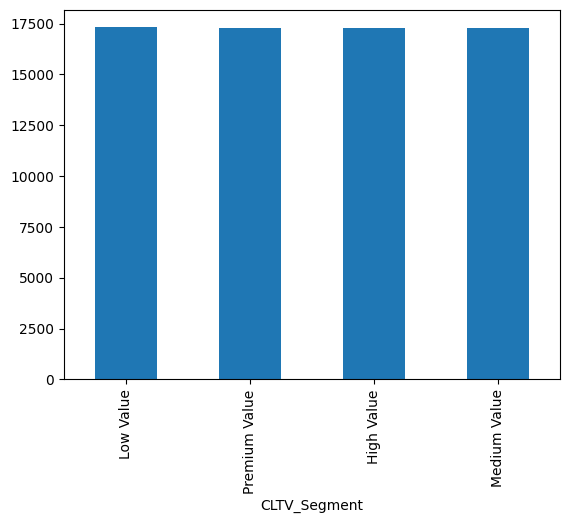

In [53]:
import matplotlib.pyplot as plt

cltv['CLTV_Segment'].value_counts().plot(kind='bar')
plt.show()

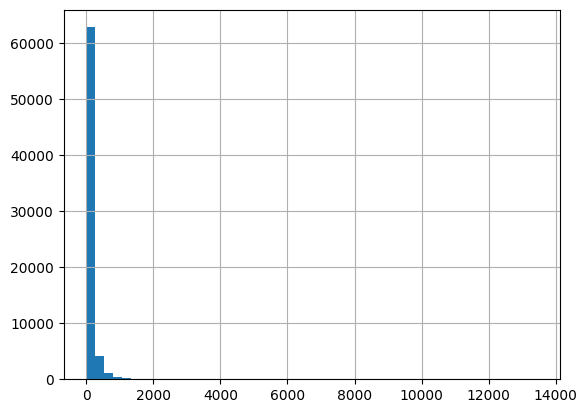

In [54]:
cltv['CLTV'].hist(bins=50)
plt.show()

In [55]:
cltv.to_csv(
    'customer_cltv.csv',
    index=False
)

print("CLTV Dataset Saved")

CLTV Dataset Saved


In [56]:
import os
os.listdir()

['.config',
 '.ipynb_checkpoints',
 'customer_cltv.csv',
 'cleaned_master_dataset.csv',
 'sample_data']